In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)


{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

In [ ]:
# Fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# Features and target
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFirst 5 Feature Rows")
display(X.head())

print("\nFirst 5 Target Rows")
display(y.head())

Features Shape: (699, 9)
Target Shape: (699, 1)

First 5 Feature Rows


,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1



First 5 Target Rows


,Class
0,2
1,2
2,2
3,2
4,2


In [ ]:
print(X.info())

print("\nMissing Values")
print(X.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 49.3 KB
None

Missing Values
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei     

In [ ]:
print(X.columns)

Index(['Clump_thickness', 'Uniformity_of_cell_size',
       'Uniformity_of_cell_shape', 'Marginal_adhesion',
       'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin',
       'Normal_nucleoli', 'Mitoses'],
      dtype='object')


In [ ]:
# Replace missing values with median
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

In [ ]:
# Convert DataFrame to Series
y = y.iloc[:,0]

# Convert labels
# 2 = Benign, 4 = Malignant

y = y.replace({
    2:0,
    4:1
})

print(y.value_counts())

Class
0    458
1    241
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(559, 9)
(140, 9)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [ ]:
print("Logistic Regression")

print("Accuracy :",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred))
print("Recall   :",recall_score(y_test,lr_pred))
print("F1 Score :",f1_score(y_test,lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test,lr_pred))

Logistic Regression
Accuracy : 0.95
Precision: 0.9361702127659575
Recall   : 0.9166666666666666
F1 Score : 0.9263157894736842

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.97      0.96        92
           1       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140



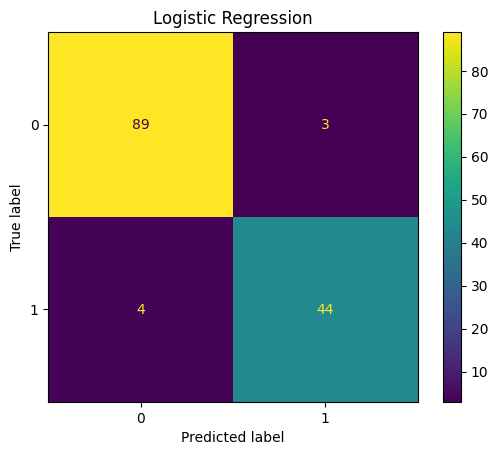

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title("Logistic Regression")

plt.show()

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest")

print("Accuracy :",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred))
print("Recall   :",recall_score(y_test,rf_pred))
print("F1 Score :",f1_score(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

Random Forest
Accuracy : 0.95
Precision: 0.9183673469387755
Recall   : 0.9375
F1 Score : 0.9278350515463918
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        92
           1       0.92      0.94      0.93        48

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.94       140
weighted avg       0.95      0.95      0.95       140



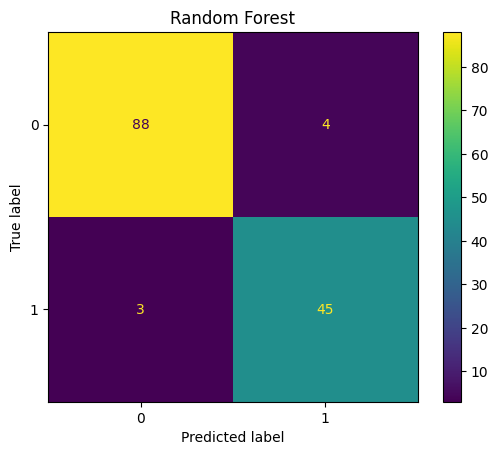

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest")

plt.show()

In [ ]:
svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [ ]:
print("Support Vector Machine")

print("Accuracy :",accuracy_score(y_test,svm_pred))
print("Precision:",precision_score(y_test,svm_pred))
print("Recall   :",recall_score(y_test,svm_pred))
print("F1 Score :",f1_score(y_test,svm_pred))

print(classification_report(y_test,svm_pred))

Support Vector Machine
Accuracy : 0.9571428571428572
Precision: 0.9375
Recall   : 0.9375
F1 Score : 0.9375
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



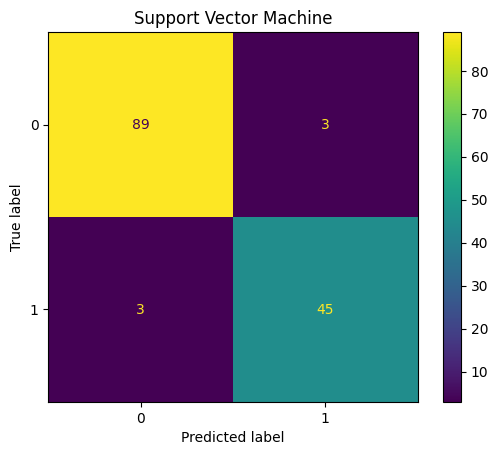

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred
)

plt.title("Support Vector Machine")

plt.show()

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,svm_pred)
    ],
    "Precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,svm_pred)
    ],
    "Recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,svm_pred)
    ],
    "F1 Score":[
        f1_score(y_test,lr_pred),
        f1_score(y_test,rf_pred),
        f1_score(y_test,svm_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.950000,0.936170,0.916667,0.926316
1,Random Forest,0.950000,0.918367,0.937500,0.927835
2,SVM,0.957143,0.937500,0.937500,0.937500


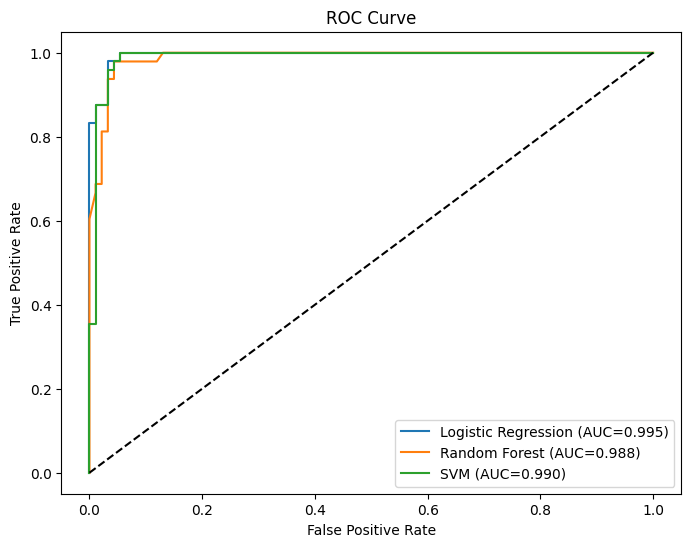

In [ ]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():

    probabilities = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

BEST Model

In [ ]:
best = results.loc[results["Accuracy"].idxmax()]

print("Best Performing Model")
print(best)

Best Performing Model
Model             SVM
Accuracy     0.957143
Precision      0.9375
Recall         0.9375
F1 Score       0.9375
Name: 2, dtype: object
